In [3]:
#Importar un archivo CSV con Pandas 
# #Se importa la librería pandas 
# # La documentación de la librería se puede ver acá: https://pandas.pydata.org/docs/ 
import pandas as pd 
#Otras librerías necesarias 
import numpy as np 
import os 
#Cambiar el directorio actual con chdir 
os.chdir('D:\Documentos\Ebac\Clases\Python\Python_avanzado')
# Se usa la función read_csv para leer el archivo.csv 
# #Se ingresa el nombre del archivo entre comillas 
# #y lo ingesta en la variable en df 
df = pd.read_csv('fifa_eda.csv')

In [4]:
df.sample(5)

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
14886,241244,R. Strain,21,Australia,60,68,Adelaide United,260.0,1.0,Right,1.0,2.0,RB,2017,2020-01-01,5.916667,168.0,377.0
1129,222400,H. Winks,22,England,77,85,Tottenham Hotspur,13000.0,66.0,Right,1.0,3.0,CM,2014,2023-01-01,5.750000,163.0,26700.0
6905,162886,R. Martin,32,Scotland,68,68,Walsall,525.0,4.0,Right,1.0,2.0,RCB,2018,2019-01-01,6.083333,187.0,919.0
4582,215502,B. Drągowski,20,Poland,71,82,Fiorentina,3200.0,15.0,Right,1.0,1.0,GK,2016,2021-01-01,6.166667,163.0,6100.0
3798,218050,M. Abarhoun,29,Morocco,72,72,Moreirense FC,2400.0,5.0,Right,1.0,2.0,RCB,2017,2019-01-01,6.166667,165.0,5100.0


In [5]:
#%pip install plotly
import plotly.express as px
import numpy as np

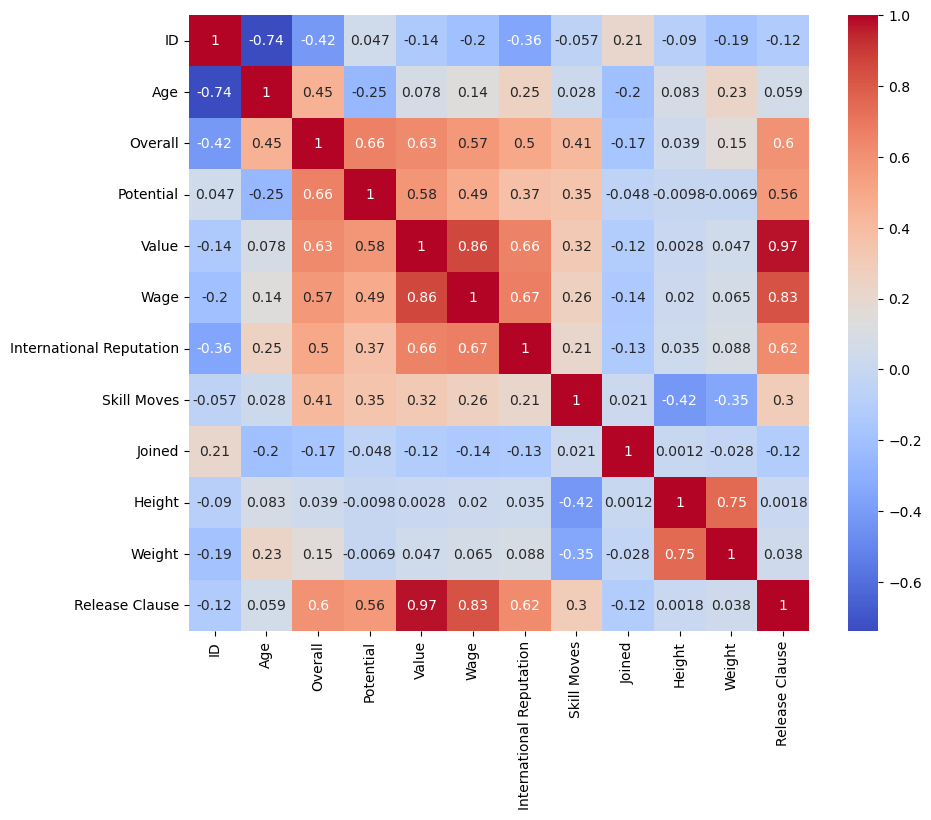

In [6]:
#obtener una matriz de correlacion y dejarla como heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [7]:
#Gráfico de Correlación que responda – “Cuál es la relación entre la edad y el overall?” – explicar la salida 
print(df[['Age', 'Overall']].head())




   Age  Overall
0   31       94
1   33       94
2   26       92
3   27       91
4   27       91


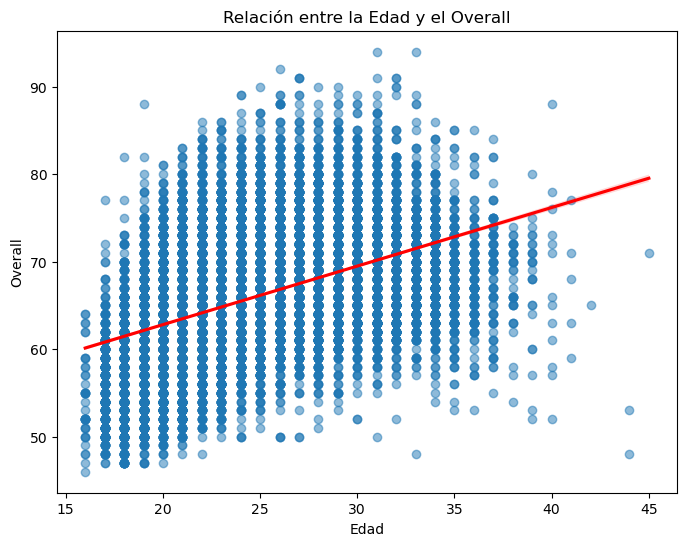

Correlación entre Edad y Overall:
             Age  Overall
Age      1.00000  0.45235
Overall  0.45235  1.00000


In [8]:
#  Crear un gráfico de correlación (scatter plot con línea de regresión)
plt.figure(figsize=(8,6))
sns.regplot(x=df['Age'], y=df['Overall'], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

#  Configurar el gráfico
plt.title("Relación entre la Edad y el Overall")
plt.xlabel("Edad")
plt.ylabel("Overall")
plt.show()

#  Calcular la correlación numérica entre Edad y Overall
correlacion = df[['Age', 'Overall']].corr()
print("Correlación entre Edad y Overall:")
print(correlacion)

In [9]:
# Crear el scatter plot interactivo
fig = px.scatter(df, x="Age", y="Overall",
                 title="Relación entre Edad y Overall",
                 labels={"Age": "Edad", "Overall": "Overall"},
                 opacity=0.6, trendline="ols")  # Agregar línea de tendencia

# Mostrar la figura
fig.show()

Interpretación del gráfico con línea ascendente
 Tendencia positiva: A medida que los jugadores envejecen, su overall tiende a aumentar, aunque no de manera estrictamente lineal.
 Posibles razones:

Los jugadores más experimentados suelen tener un overall más alto debido a su desarrollo profesional.
Los jóvenes pueden tener overall variable, ya que algunos son estrellas en ascenso y otros están en formación.

In [10]:
#generar un grafico de barras por club que indique el numero de jugadores
# Contar el número de jugadores por club
club_counts = df["Club"].value_counts().reset_index()
club_counts.columns = ["Club", "Número de Jugadores"]

# Crear el gráfico de barras
fig = px.bar(club_counts, x="Club", y="Número de Jugadores",
             title="Número de jugadores por club",
             labels={"Club": "Club", "Número de Jugadores": "Cantidad de jugadores"},
             text_auto=True)

# Ajustar la orientación si hay muchos clubes
fig.update_layout(xaxis={'categoryorder': 'total descending'},
                  xaxis_tickangle=-45)  # Rotar etiquetas del eje X

# Mostrar el gráfico
fig.show()


In [11]:
#hacer un grafico multipanel que indique la relacion de altura (heigth) vs skill moves siendo la variable del panel si es zurdo o derecho
df["Foot"] = df["Preferred Foot"].replace({"Left": "Zurdo", "Right": "Diestro"})

# Crear el gráfico de dispersión con paneles (facetado)
fig = px.scatter(df, x="Height", y="Skill Moves",
                 color="Skill Moves",  # Colorear según Skill Moves
                 facet_col="Foot",  # Crear paneles por pie dominante
                 title="Relación entre Altura y Skill Moves (por Pie Dominante)",
                 labels={"Height": "Altura (cm)", "Skill Moves": "Movimientos de Habilidad", "Foot": "Pie Dominante"},
                 opacity=0.6)

# Ajustar el diseño
fig.update_layout(showlegend=False)  # Ocultar leyenda redundante

# Mostrar el gráfico
fig.show()


c:\Users\ego_2\anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [12]:
#Un gráfico que crea importante para mostrar a los potenciales cracks
#calcular la diferencia entre el overall y el potential
df["Diferencia"] = df["Potential"] - df["Overall"]

#crear el scatter plot
fig = px.scatter(df, x="Overall", y="Potential",
                 color="Diferencia",  # Resaltar jugadores con mayor diferencia
                 size="Diferencia",    # Tamaño de puntos según su potencial de crecimiento
                 hover_name="Name",    # Mostrar el nombre del jugador al pasar el mouse
                 title="Jugadores con Mayor Potencial de Crecimiento",
                 labels={"Overall": "Valoración Actual", "Potential": "Potencial"},
                 opacity=0.7)

# Mostrar el gráfico
fig.show()

In [17]:
#filtrar solo jugadores con alto pontencial
df_filtered = df[df["Potential"] > 92]
fig = px.scatter(df_filtered, x="Overall", y="Potential", color="Diferencia", size="Diferencia", hover_name="Name", text="Name")
fig.update_traces(textposition="top center")
fig.show()


Mbappe, Dybala, Oblak, de gea, De Bruyne segun el analisis son las futuras estrellas

In [14]:
#agregar la edad al analisis para ver futuras estrellas
fig = px.scatter(df, x="Overall", y="Potential", color="Age", size="Diferencia", hover_name="Name")
fig.show()


Ayeva, Campbell, von Moos, Lenze son algunos de los cracks en potencia